# SPLICE Demo

Decomposes geospatial embeddings into sparse nonnegative combinations of text concept embeddings using SPLICE.

Loads the alignment model from a checkpoint directory and concepts from a JSON file.

## Setup

In [181]:
import sys
import json
import os
from pathlib import Path
import yaml

In [182]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

In [183]:
REPO_ROOT = Path("..").resolve()
SPLICE_DIR = REPO_ROOT / "src" / "explainability" / "splice"
LOCATION_TEXT_ALIGNMENT_DIR = SPLICE_DIR / "location_text_alignment"

In [184]:
for p in [str(LOCATION_TEXT_ALIGNMENT_DIR), str(SPLICE_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

In [185]:
from eval_reconstruction import load_model, load_concept_embeddings, load_latlons, build_splice, compute_reconstruction

## Configuration

In [186]:
CONFIG_PATH = REPO_ROOT / "configs" / "eval_reconstruction.yaml"
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

In [187]:
MODEL_NAME = "geoclip"

In [188]:
model_cfg  = cfg["models"][MODEL_NAME]

MODEL_PATH = (
    Path(model_cfg["root"]).expanduser()
    / model_cfg["checkpoint"]
)

L1_PENALTY = model_cfg["l1_penalty"]
CONCEPT_SET = Path(cfg["concept_set"]).expanduser()
DENSE_GRID_CSV = Path(cfg["datasets"]["dense_grid"]).expanduser()


In [189]:
print(f"Model : {MODEL_PATH}")
print(f"L1 : {L1_PENALTY}")

Model : /home/user/outputs/explainable-earth-embeddings/geoclip_init.pt
L1 : 0.25


In [190]:
BATCH_SIZE = 512
PROMPT = "An image of a {concept}"

In [191]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## Load Alignment Model

In [192]:
model = load_model(MODEL_PATH, device)
print("Model loaded.")

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 3191.96it/s]


Model loaded.


## Load Concepts

In [193]:
with open(CONCEPT_SET) as f:
    concepts = json.load(f)

emb_concepts = load_concept_embeddings(model, CONCEPT_SET, device)
print(f"Loaded {len(concepts)} concepts, embeddings: {emb_concepts.shape}")

Loaded 203 concepts, embeddings: torch.Size([203, 512])


## Load Dense Grid Sample (reference distribution for SPLICE)

In [194]:
df = pd.read_csv(DENSE_GRID_CSV)
df = df.reset_index(drop=True)
latlons = torch.tensor(df[["lat", "lon"]].values, dtype=torch.float32).to(device)
print(f"Reference points: {latlons.shape}")

Reference points: torch.Size([10000, 2])


## Build SPLICE Model

In [195]:
splice_model = build_splice(model, emb_concepts, latlons, L1_PENALTY, device)

Using ADMM solver...
With rho value 5.0


## Reconstruction Metrics

In [196]:
orig, weights, recon = compute_reconstruction(splice_model, latlons)

100%|██████████| 20/20 [00:01<00:00, 14.67it/s]


In [197]:
mse = F.mse_loss(recon, orig).item()
cos_sim = (recon * orig).sum(dim=1).mean().item()
l0_mean = (weights > 0).float().sum(dim=1).mean().item()

In [198]:
print(
    f"mse: {mse:.6f}\n"
    f"cosine_similarity: {cos_sim:.4f}\n"
    f"mean_active_concepts_l0: {l0_mean:.1f}\n"
    f"num_concepts: {int(weights.shape[1])}\n"
    f"num_samples: {int(len(orig))}"
)

mse: 0.002411
cosine_similarity: 0.3827
mean_active_concepts_l0: 4.4
num_concepts: 203
num_samples: 10000


## Concept Decompositions

In [199]:
colors = {
    "Paris":   "#3a86ff",
    "Sahara":  "#e76f51",
    "Siberia": "#588157",
    "Bali":    "#9b5de5",
}

In [200]:
# Replace with desired locations
locations = {
    "Paris":   (48.8584,   2.2945),
    "Sahara":  (22.2348,   7.9586),
    "Siberia": (61.5240, 105.3188),
    "Bali":    (-8.4095, 115.1889),
}

In [201]:
# Number of concepts displayed
TOP_K = 4

In [202]:
def _decompose_latlon(lat, lon):
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device=device)
    with torch.no_grad():
        raw = splice_model.clip.encode_image(latlon)
        orig_b = F.normalize(raw, dim=1)
        w_b = splice_model.decompose(F.normalize(orig_b - splice_model.image_mean, dim=1))
    return w_b[0]

## Print Concept Decompositions

In [203]:
for name, (lat, lon) in locations.items():
    w = _decompose_latlon(lat, lon)
    top_k = [(c, v) for c, v in sorted(zip(concepts, w.tolist()), key=lambda x: -x[1]) if v > 0][:TOP_K]
    print(f"{name}:")
    for concept, val in top_k:
        print(f"  {concept}: {val:.4f}")
    print()

Paris:
  park: 0.0506
  city: 0.0310

Sahara:
  desert: 0.1019
  badland: 0.0709
  canyon: 0.0235
  subalpine: 0.0010

Siberia:
  steppe: 0.1093
  taiga: 0.0774
  boreal: 0.0064
  monument: 0.0022

Bali:
  inlet: 0.0870
  volcano: 0.0653
  mangrove: 0.0121



## Visualize Concept Decompositions

In [204]:
loc_decompositions = {}
for name, (lat, lon) in locations.items():
    w = _decompose_latlon(lat, lon)
    pairs = [(c, v) for c, v in sorted(zip(concepts, w.tolist()), key=lambda x: -x[1]) if v > 0][:TOP_K]
    loc_decompositions[name] = pairs

all_vals = [v for pairs in loc_decompositions.values() for _, v in pairs]
xmax = max(all_vals) * 1.12 if all_vals else 1.0


plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size":       14,
    "axes.titlesize":  16,
    "axes.labelsize":  14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 13,
})

Paris


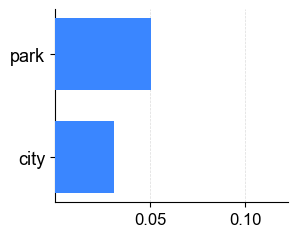

Sahara


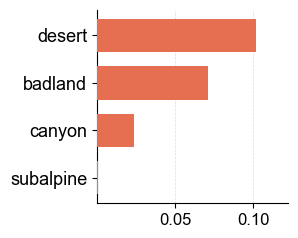

Siberia


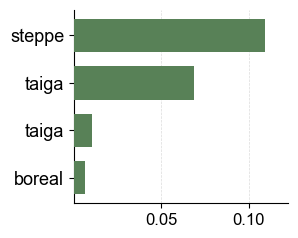

Bali


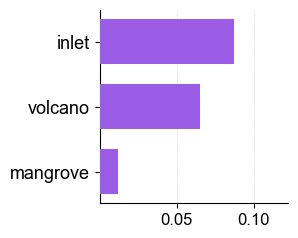

In [205]:
for name, (lat, lon) in locations.items():
    pairs = loc_decompositions[name]
    if not pairs:
        continue

    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    fig, ax = plt.subplots(figsize=(3.2, 2.6))
    ax.barh(y, vals, height=0.7, color=colors[name], edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([c for c in labels])
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    #ax.set_title(name)
    print(name)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.grid(axis="x", linewidth=0.5, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
    plt.tight_layout()
    plt.show()

## Polygon / Region Decomposition

Instead of a single point, you can compute SPLICE over a **grid of points inside a polygon** and aggregate the weights.

**Two ways to define the polygon:**

**Option: inline coordinates** using `shapely.geometry.Polygon`.  
Shapely uses **(lon, lat)** order (x = longitude, y = latitude).

**Option: shapefile** loaded with `geopandas`.  
Any format GDAL supports (`.shp`, `.geojson`, `.gpkg`, etc.) works.  
Call `.to_crs("EPSG:4326")` first if the file is not already in WGS-84.

After choosing a polygon, `grid_in_polygon` samples it on a regular degree grid, then SPLICE weights are averaged across all interior points to give a single regional decomposition.

In [206]:
import geopandas as gpd
from shapely.geometry import Point, Polygon

In [207]:
def grid_in_polygon(polygon, resolution_deg=0.5):
    """Return (lat, lon) pairs on a regular grid that fall inside polygon.

    polygon      – shapely Polygon/MultiPolygon in (lon, lat) / EPSG:4326
    resolution_deg – grid spacing in degrees
    """
    minx, miny, maxx, maxy = polygon.bounds  # minx=lon_min, miny=lat_min
    lons = np.arange(minx, maxx + resolution_deg, resolution_deg)
    lats = np.arange(miny, maxy + resolution_deg, resolution_deg)
    return [
        (lat, lon)
        for lat in lats
        for lon in lons
        if polygon.contains(Point(lon, lat))
    ]

## Region Decompositions from Shapefiles

In [208]:
SHAPEFILE_DIR = Path("~/data/shapefiles/splice_concepts").expanduser()

In [209]:
gdf_fr = gpd.read_file(f"/vsigzip/{SHAPEFILE_DIR}/communes-5m.geojson.gz")
poly_paris = gdf_fr[gdf_fr["nom"] == "Paris"].geometry.iloc[0]

In [210]:
gdf_idn = gpd.read_file(f"zip://{SHAPEFILE_DIR}/gadm41_IDN_shp.zip", layer="gadm41_IDN_1")
poly_bali = gdf_idn[gdf_idn["NAME_1"] == "Bali"].geometry.iloc[0]

In [211]:
gdf_sah = gpd.read_file(f"zip://{SHAPEFILE_DIR}/sahara.zip").to_crs("EPSG:4326")
poly_sahara = gdf_sah.geometry.iloc[0]

In [212]:
SIBERIAN_REGIONS = [
    "Altay", "Gorno-Altay", "Buryat", "Irkutsk", "Kemerovo",
    "Khakass", "Krasnoyarsk", "Novosibirsk", "Omsk", "Tomsk",
    "Tuva", "Zabaykal'ye",
]
gdf_rus = gpd.read_file(f"zip://{SHAPEFILE_DIR}/gadm41_RUS_shp.zip", layer="gadm41_RUS_1")
poly_siberia = gdf_rus[gdf_rus["NAME_1"].isin(SIBERIAN_REGIONS)].dissolve().geometry.iloc[0]


In [213]:
region_polys = {
    "Paris":   poly_paris,
    "Bali":    poly_bali,
    "Sahara":  poly_sahara,
    "Siberia": poly_siberia,
}


In [214]:
for name, poly in region_polys.items():
    print(f"{name}: bounds = {tuple(round(v, 2) for v in poly.bounds)}")

Paris: bounds = (2.22, 48.82, 2.47, 48.9)
Bali: bounds = (114.43, -8.85, 115.71, -8.06)
Sahara: bounds = (-17.07, 9.34, 38.46, 34.61)
Siberia: bounds = (70.42, 49.08, 122.09, 81.28)


In [215]:
RESOLUTION_DEG = 0.5

region_decompositions = {}
for name, poly in region_polys.items():
    pts = grid_in_polygon(poly, RESOLUTION_DEG)
    if not pts:
        c = poly.centroid
        pts = [(c.y, c.x)]  # (lat, lon)
        print(f"{name}: no grid points found, using centroid ({c.y:.4f}, {c.x:.4f})")
    grid_latlons = torch.tensor(pts, dtype=torch.float32, device=device)
    with torch.no_grad():
        raw = splice_model.clip.encode_image(grid_latlons)
        orig_g = F.normalize(raw, dim=1)
        grid_weights = splice_model.decompose(
            F.normalize(orig_g - splice_model.image_mean, dim=1)
        )
    mean_w = grid_weights.mean(0)
    top_k = [
        (c, v)
        for c, v in sorted(zip(concepts, mean_w.tolist()), key=lambda x: -x[1])
        if v > 0
    ][:TOP_K]
    region_decompositions[name] = top_k
    print(f"{name} ({len(pts)} pts):")
    for concept, val in top_k:
        print(f"  {concept}: {val:.4f}")
    print()

Paris: no grid points found, using centroid (48.8566, 2.3429)
Paris (1 pts):
  canal: 0.0357
  plateau: 0.0119
  inlet: 0.0067
  drainage: 0.0046

Bali (2 pts):
  pier: 0.0379
  inlet: 0.0368
  volcano: 0.0297
  tropical: 0.0090

Sahara (3717 pts):
  desert: 0.0633
  wadi: 0.0460
  badland: 0.0116
  mesa: 0.0063

Siberia (3530 pts):
  permafrost: 0.0351
  boreal: 0.0260
  subalpine: 0.0146
  steppe: 0.0140



Paris


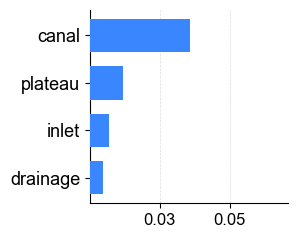

Bali


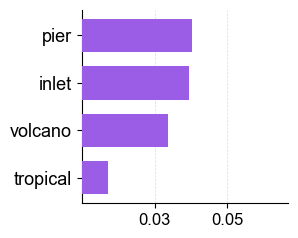

Sahara


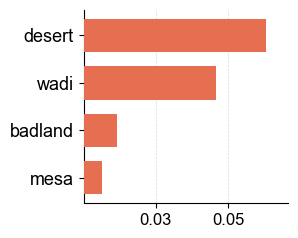

Siberia


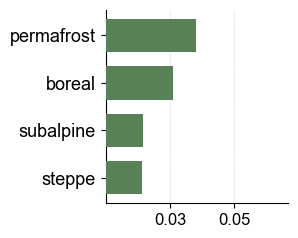

In [ ]:
all_region_vals = [v for pairs in region_decompositions.values() for _, v in pairs]
xmax_region = max(all_region_vals) * 1.12 if all_region_vals else 1.0

for name, pairs in region_decompositions.items():
    if not pairs:
        continue

    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    fig, ax = plt.subplots(figsize=(3.2, 2.6))
    ax.barh(y, vals, height=0.7, color=colors[name], edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels([c for c in labels])
    ax.invert_yaxis()
    ax.set_xlim(0, xmax_region)
    #ax.set_title(name)
    print(name)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.8)
    ax.grid(axis="x", linewidth=0.5, linestyle="--", color="#cccccc", alpha=0.7, zorder=0)
    plt.tight_layout()
    fig.savefig(f'{MODEL_NAME}_{name}_region_top_4.png', dpi=300)
    plt.show()